# Pythia8 + FastJet: anti-$k_t$ b-jet response vs. R and $p_T$

Builds on `demo_pythia_fastjet.ipynb` from https://github.com/matplo/heppyyier. We generate $b\bar b$ events with Pythia8 (`HardQCD:hardbbbar`), cluster anti-$k_t$ jets at mid-rapidity ($|\eta_{jet}| < 2.5$) for several radii $R \in [0.1, 0.6]$, match each jet to the outgoing b-quark from the hard process, and study the jet $p_T$ response as a function of $R$ and
the b-quark $p_T$ (scanned from 10 to 100 GeV/c in steps of 10 GeV/c):

- per-R response profiles and a most-probable-value summary
- the raw jet-$p_T$ vs. b-quark-$p_T$ correlation
- matching debug plots ($\Delta y$ vs. $\Delta\phi$) and ratio distributions at example $p_T$ points
- the same response study restricted to charged final-state particles only

In [1]:
# heppyyier.load() is a no-op if packages were already loaded via
# `module load` or the heppyyier Jupyter kernel. Safe to leave in place.
import heppyyier
heppyyier.load('pythia8')
heppyyier.load('fastjet')

/Users/ploskon/.henvs/default/lib/python3.14/site-packages/cppyy/__init__.py:383: UserWarning: CPyCppyy API not found (tried: /Users/ploskon/.henvs/default/lib/python3.14/site-packages/cppyy_backend/include); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [2]:
import time
import cppyy
import pythia8
import fastjet
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Sanity check: cppyy location
print(f"cppyy from: {cppyy.__file__}")

PseudoJetVec = cppyy.gbl.std.vector[fastjet.PseudoJet]

cppyy from: /Users/ploskon/.henvs/default/lib/python3.14/site-packages/cppyy/__init__.py


## Configure Pythia8 for b-jet production

`HardQCD:hardbbbar = on` selects the $gg,\, q\bar q \to b\bar b$ hard 2$\to$2 processes, i.e. genuine
heavy-flavor pair production (as opposed to $b\bar b$ pairs from gluon splitting in the shower).

The b-quark production cross section falls steeply with $p_T$, so a single Pythia run would leave the
high-$p_T$ end of our 10-100 GeV/c range statistics-starved. Instead we run one Pythia instance **per target
bin**, each with `PhaseSpace:pTHatMin` set to that bin's lower edge and **no `pTHatMax`** (left at its Pythia
default of "unbounded") -- so within each run, events concentrate near that bin's own threshold, exactly
where we want the statistics. Events are then sorted into bins by their *actual* generated b-quark $p_T$
(not by which run produced them), so the high-$p_T$ tail of a low-threshold run also contributes bonus
statistics to the bins above it -- there's no need to cap each run's upper end.

In [3]:
# --- Analysis parameters ---
R_values          = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]   # anti-kT jet radii to scan
pt_edges          = np.arange(10.0, 101.0, 10.0)      # b-quark pT bin edges [10,20,...,100] GeV/c
pt_centers        = 0.5 * (pt_edges[:-1] + pt_edges[1:])
eta_cut           = 2.5    # |eta_jet| < eta_cut  (mid-rapidity)
jet_pt_min        = 2.0    # GeV, min pT passed to the jet finder's inclusive_jets()
ratio_range       = (0.0, 2.0)   # histogram / KDE range for the jet-pT / b-quark-pT ratio

# Events generated per pT-hat bin -- one Pythia run per bin, keyed by that bin's pTHatMin (see
# build_pythia / run_scan below). Uniform by default; edit individual entries to add more statistics
# to specific bins, e.g. n_events_per_bin[pt_edges[-2]] = 4000 for the highest-pT bin.
N_EVENTS_DEFAULT  = 2000
n_events_per_bin  = {lo: N_EVENTS_DEFAULT for lo in pt_edges[:-1]}

# b-quark pT value(s) [GeV/c] used for the matching-debug and ratio-distribution example plots below.
# Set e.g. EXAMPLE_PT_BINS = list(pt_centers) to produce one figure per pT bin instead of a single example.
EXAMPLE_PT_BINS   = [50.0]

COLOR_ALL         = '#4C72B0'   # jets built from all final-state particles
COLOR_CHARGED     = '#55A868'   # jets built from charged final-state particles only
COLOR_ACCENT      = '#C44E52'   # reference lines / medians in debug plots

print(f'R values          : {R_values}')
print(f'b-quark pT bins   : {list(pt_edges)} GeV/c')
print(f'eta cut (jets)    : |eta| < {eta_cut}')
print(f'example pT bin(s) : {EXAMPLE_PT_BINS} GeV/c')
print('events per pT-hat bin (pTHatMin -> n_events):')
for lo, n_ev in n_events_per_bin.items():
    print(f'  {lo:>5.0f} GeV/c -> {n_ev}')

R values          : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
b-quark pT bins   : [np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(90.0), np.float64(100.0)] GeV/c
eta cut (jets)    : |eta| < 2.5
example pT bin(s) : [50.0] GeV/c
events per pT-hat bin (pTHatMin -> n_events):
     10 GeV/c -> 2000
     20 GeV/c -> 2000
     30 GeV/c -> 2000
     40 GeV/c -> 2000
     50 GeV/c -> 2000
     60 GeV/c -> 2000
     70 GeV/c -> 2000
     80 GeV/c -> 2000
     90 GeV/c -> 2000


## Helper functions

In [4]:
FIELDS = ['R', 'pt_bin', 'b_pt', 'b_eta', 'b_rap', 'b_phi',
          'jet_pt', 'jet_eta', 'jet_rap', 'jet_phi', 'dR']


def build_pythia(ptHatMin):
    """Configure and initialize a fresh Pythia8 instance for hard b bbar production.

    Only a lower pTHat threshold is set; pTHatMax is left at its Pythia default (unbounded), see
    the "Configure Pythia8" markdown cell above for why that's the right choice here.
    """
    p = pythia8.Pythia()
    p.readString('Beams:eCM = 13000.')
    p.readString('HardQCD:hardbbbar = on')   # gg, qqbar -> b bbar hard process
    p.readString(f'PhaseSpace:pTHatMin = {ptHatMin}')
    p.readString('Next:numberShowEvent = 0')
    p.readString('Print:quiet = on')
    p.init()
    return p


def outgoing_bquarks(event):
    """Outgoing b/bbar quarks from the hard 2->2 process (status +-23)."""
    return [event[i] for i in range(event.size())
            if abs(event[i].id()) == 5 and event[i].statusAbs() == 23]


def final_state_pseudojets(event, charged_only=False):
    """PseudoJet vector of final, visible particles for jet clustering.

    charged_only restricts to charged particles, mimicking a track-based
    (charged-particle) b-jet reconstruction.
    """
    particles = PseudoJetVec()
    for i in range(event.size()):
        p = event[i]
        if p.isFinal() and p.isVisible() and (not charged_only or p.isCharged()):
            particles.push_back(fastjet.PseudoJet(p.px(), p.py(), p.pz(), p.e()))
    return particles


def wrap_phi(dphi):
    """Wrap an angle difference into (-pi, pi]."""
    return (dphi + np.pi) % (2 * np.pi) - np.pi


def bin_index_for_pt(value, edges=pt_edges):
    """Index of the [edges[i], edges[i+1]) bin containing value, or None if outside."""
    idx = int(np.digitize(value, edges)) - 1
    return idx if 0 <= idx < len(edges) - 1 else None


def finalize_data(raw):
    """Convert a dict of lists (one entry per matched pair) into arrays with derived quantities.

    delta_y (not delta_eta) is used for the matching-debug plot: FastJet's PseudoJet.delta_R()
    -- the actual matching metric -- is defined with rapidity y, not pseudorapidity eta, and the
    b-quark's mass (~4.8 GeV) makes the difference between the two non-negligible near threshold.
    """
    data = {k: np.array(v) for k, v in raw.items()}
    data['pt_ratio']  = data['jet_pt'] / data['b_pt']
    data['delta_y']   = data['jet_rap'] - data['b_rap']
    data['delta_phi'] = wrap_phi(data['jet_phi'] - data['b_phi'])
    return data


def most_probable(values, vrange=ratio_range, min_count=30, grid_size=400):
    """Mode ('most probable value') of an array of ratios, via a Gaussian KDE.

    A KDE is far less noisy than a raw histogram argmax, which tends to jump
    erratically between comparably-tall bins when the underlying distribution
    is broad or mildly bimodal (as the small-R response often is).
    """
    values = np.asarray(values)
    values = values[(values >= vrange[0]) & (values <= vrange[1])]
    if len(values) < min_count:
        return np.nan
    kde = gaussian_kde(values)
    grid = np.linspace(vrange[0], vrange[1], grid_size)
    return grid[np.argmax(kde(grid))]


def profile(x, y, edges, min_count=10):
    """Median and 16-84 percentile band of y, binned in x."""
    centers, med, p16, p84, n = [], [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        centers.append(0.5 * (lo + hi))
        n.append(int(m.sum()))
        if m.sum() < min_count:
            med.append(np.nan); p16.append(np.nan); p84.append(np.nan)
            continue
        med.append(np.median(y[m]))
        p16.append(np.percentile(y[m], 16))
        p84.append(np.percentile(y[m], 84))
    return np.array(centers), np.array(med), np.array(p16), np.array(p84), np.array(n)

## Run the scan: generate events, cluster jets, match to b-quarks

`run_scan()` runs one Pythia instance per pT-hat bin (`PhaseSpace:pTHatMin` = that bin's lower edge, no
`pTHatMax`), generating `n_events_per_bin[lo]` events. For each event it builds jets from both the
all-particle and charged-particle-only final states (`track_types`), reusing the same generated event for
both -- clustering is cheap, event generation is not. Each outgoing b-quark is matched to the closest
accepted jet ($|\eta_{jet}| < \eta_{cut}$) in $\Delta R$; the match is kept if $\Delta R < R$, i.e. the
b-quark direction falls inside the jet's own cone.

In [5]:
def run_scan(track_types=('all', 'charged'), R_values=R_values, pt_edges=pt_edges,
             eta_cut=eta_cut, jet_pt_min=jet_pt_min, n_events_per_bin=n_events_per_bin):
    """Generate events once per pT-hat bin and build matched (b-quark, jet) pairs for each track type."""
    jet_defs = {R: fastjet.JetDefinition(fastjet.antikt_algorithm, R) for R in R_values}
    raw = {tt: {k: [] for k in FIELDS} for tt in track_types}

    t_start = time.time()
    for lo in pt_edges[:-1]:
        pythia = build_pythia(lo)
        n_matched_bin = {tt: 0 for tt in track_types}
        for _ in range(n_events_per_bin[lo]):
            if not pythia.next():
                continue
            bquarks = outgoing_bquarks(pythia.event)
            if not bquarks:
                continue

            for tt in track_types:
                particles = final_state_pseudojets(pythia.event, charged_only=(tt == 'charged'))
                for R in R_values:
                    cs = fastjet.ClusterSequence(particles, jet_defs[R])
                    jets = [j for j in cs.inclusive_jets(jet_pt_min) if abs(j.eta()) < eta_cut]
                    if not jets:
                        continue
                    for b in bquarks:
                        b_pt = b.pT()
                        idx = bin_index_for_pt(b_pt, pt_edges)
                        if idx is None:
                            continue
                        bp4 = fastjet.PseudoJet(b.px(), b.py(), b.pz(), b.e())
                        best, best_dr = None, 1e9
                        for jet in jets:
                            dr = bp4.delta_R(jet)
                            if dr < best_dr:
                                best_dr, best = dr, jet
                        if best is not None and best_dr < R:
                            d = raw[tt]
                            d['R'].append(R)
                            d['pt_bin'].append(idx)
                            d['b_pt'].append(b_pt)
                            d['b_eta'].append(b.eta())
                            d['b_rap'].append(bp4.rap())
                            d['b_phi'].append(b.phi())
                            d['jet_pt'].append(best.pt())
                            d['jet_eta'].append(best.eta())
                            d['jet_rap'].append(best.rap())
                            d['jet_phi'].append(best.phi_std())
                            d['dR'].append(best_dr)
                            n_matched_bin[tt] += 1
        del pythia
        counts_str = ', '.join(f'{tt}={n_matched_bin[tt]}' for tt in track_types)
        print(f'pTHatMin={lo:.0f} GeV ({n_events_per_bin[lo]} events): matched pairs -> {counts_str}')

    results = {tt: finalize_data(raw[tt]) for tt in track_types}
    print(f'\nTotal elapsed: {time.time() - t_start:.1f} s')
    for tt in track_types:
        print(f'  {tt}: {len(results[tt]["R"])} matched pairs')
    return results

In [6]:
results = run_scan()
data         = results['all']       # jets from all final-state particles
data_charged = results['charged']   # jets from charged final-state particles only


 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.317      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 20 Jan 2026  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 30 Jul 2026 at 11:05:05    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

## Plotting helpers

Reusable functions for every figure below; each takes a `data` dict as returned inside `results` from
`run_scan()`.

In [7]:
def plot_perR_ratio(data, suptitle, color=COLOR_ALL, ylabel=r'jet $p_T$ / b-quark $p_T$',
                     R_values=R_values, pt_edges=pt_edges, savepath=None):
    """2x3 grid: median jet_pT/b_pT ratio (+16-84% band) vs. b-quark pT, one panel per R."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    fig.suptitle(suptitle)
    for idx, (ax, R) in enumerate(zip(axes.flat, R_values)):
        m = data['R'] == R
        bpt = data['b_pt'][m]
        c, med, lo_, hi_, n = profile(bpt, data['pt_ratio'][m], pt_edges)
        ax.plot(c, med, '-o', color=color, ms=4)
        ax.fill_between(c, lo_, hi_, color=color, alpha=0.2, linewidth=0)
        ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
        ax.set_title(f'R = {R}  ({m.sum()} pairs)')
        ax.set_ylim(0, 1.6)
        row, col = divmod(idx, 3)
        if row == 1:
            ax.set_xlabel(r'b-quark $p_T$ [GeV/c]')
        if col == 0:
            ax.set_ylabel(f'{ylabel} (median ± 16-84%)')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()
    return fig


def plot_summary_mpv(data, suptitle, R_values=R_values, pt_edges=pt_edges, pt_centers=pt_centers,
                      ratio_range=ratio_range, savepath=None):
    """Most-probable-value (KDE mode) of jet_pT/b_pT vs. b-quark pT, one curve per R."""
    mpv = np.full((len(R_values), len(pt_centers)), np.nan)
    counts = np.zeros((len(R_values), len(pt_centers)), dtype=int)
    for iR, R in enumerate(R_values):
        for ib in range(len(pt_centers)):
            m = (data['R'] == R) & (data['pt_bin'] == ib)
            counts[iR, ib] = m.sum()
            mpv[iR, ib] = most_probable(data['pt_ratio'][m], vrange=ratio_range)

    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=min(R_values), vmax=max(R_values))

    fig, ax = plt.subplots(figsize=(7, 5))
    for iR, R in enumerate(R_values):
        ax.plot(pt_centers, mpv[iR], '-o', ms=4, color=cmap(norm(R)))
    ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel(r'b-quark $p_T$ [GeV/c]')
    ax.set_ylabel('most probable value')
    ax.set_title(r'jet $p_T$ / b-quark $p_T$')
    ax.set_ylim(0, 1.3)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, ticks=R_values)
    cbar.set_label(r'anti-$k_t$ jet radius R')

    fig.suptitle(suptitle)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    print('Matched-pair counts per (R, pT bin) -- low counts make the MPV noisy:')
    header = '        ' + ''.join(f'{c:>7.0f}' for c in pt_centers)
    print(header)
    for iR, R in enumerate(R_values):
        print(f'R={R:<5.1f} ' + ''.join(f'{counts[iR, ib]:>7d}' for ib in range(len(pt_centers))))
    return fig


def plot_pt_correlation(data, suptitle, R_values=R_values, pt_edges=pt_edges, savepath=None):
    """2x3 grid: jet pT vs. b-quark pT (all matched pairs, full pT range), one panel per R."""
    lo_edge, hi_edge = pt_edges.min(), pt_edges.max()
    y_max = 1.3 * hi_edge
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    fig.suptitle(suptitle)
    for idx, (ax, R) in enumerate(zip(axes.flat, R_values)):
        m = data['R'] == R
        ax.hexbin(data['b_pt'][m], data['jet_pt'][m], gridsize=40, mincnt=1,
                  extent=(lo_edge, hi_edge, 0, y_max), cmap='viridis')
        ax.plot([lo_edge, hi_edge], [lo_edge, hi_edge], color='white', linestyle='--', linewidth=1)
        ax.set_title(f'R = {R}  ({m.sum()} pairs)')
        row, col = divmod(idx, 3)
        if row == 1:
            ax.set_xlabel(r'b-quark $p_T$ [GeV/c]')
        if col == 0:
            ax.set_ylabel(r'jet $p_T$ [GeV/c]')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()
    return fig


def plot_matching_debug(data, pt_value, suptitle_prefix, R_values=R_values, pt_edges=pt_edges,
                         accent=COLOR_ACCENT, savepath=None):
    """2x3 grid: delta_y vs delta_phi of matched pairs in the pT bin containing pt_value.

    delta_y (rapidity difference) is used, not delta_eta, to match FastJet's own delta_R metric
    exactly -- see finalize_data(). Every point falls inside the R circle by construction.
    """
    idx = bin_index_for_pt(pt_value, pt_edges)
    lo, hi = pt_edges[idx], pt_edges[idx + 1]
    lim = 1.3 * max(R_values)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    fig.suptitle(f'{suptitle_prefix}  (b-quark $p_T$ in [{lo:.0f},{hi:.0f}) GeV/c)')
    theta = np.linspace(0, 2 * np.pi, 200)
    for i, (ax, R) in enumerate(zip(axes.flat, R_values)):
        m = (data['R'] == R) & (data['pt_bin'] == idx)
        ax.scatter(data['delta_y'][m], data['delta_phi'][m], s=6, alpha=0.4, color=COLOR_ALL)
        ax.plot(R * np.cos(theta), R * np.sin(theta), color=accent, linewidth=1.2)
        ax.set_title(f'R = {R}  ({m.sum()} pairs)')
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        row, col = divmod(i, 3)
        if row == 1:
            ax.set_xlabel(r'$\Delta y$ (jet $-$ b-quark)')
        if col == 0:
            ax.set_ylabel(r'$\Delta\phi$ (jet $-$ b-quark)')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()
    return fig


def plot_ratio_distribution(data, pt_value, suptitle_prefix, R_values=R_values, pt_edges=pt_edges,
                             ratio_range=ratio_range, accent=COLOR_ACCENT, savepath=None):
    """2x3 grid: jet_pT/b_pT histogram of matched pairs in the pT bin containing pt_value."""
    idx = bin_index_for_pt(pt_value, pt_edges)
    lo, hi = pt_edges[idx], pt_edges[idx + 1]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    fig.suptitle(f'{suptitle_prefix}  (b-quark $p_T$ in [{lo:.0f},{hi:.0f}) GeV/c)')
    for i, (ax, R) in enumerate(zip(axes.flat, R_values)):
        m = (data['R'] == R) & (data['pt_bin'] == idx)
        vals = data['pt_ratio'][m]
        ax.hist(vals, bins=40, range=ratio_range, histtype='step', color=COLOR_ALL, linewidth=1.5)
        ax.axvline(1.0, color='gray', linewidth=0.8, linestyle=':')
        if len(vals):
            ax.axvline(np.median(vals), color=accent, linewidth=1.2, label='median')
        ax.set_title(f'R = {R}  ({m.sum()} pairs)')
        ax.set_yscale('log')
        row, col = divmod(i, 3)
        if row == 1:
            ax.set_xlabel(r'jet $p_T$ / b-quark $p_T$')
        if col == 0:
            ax.set_ylabel('pairs / bin')
    axes.flat[0].legend(fontsize=8)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()
    return fig

## Results for individual R's

For each jet radius: median jet $p_T$ / b-quark $p_T$ (points) and 16–84 percentile spread (band) vs. the
b-quark $p_T$.

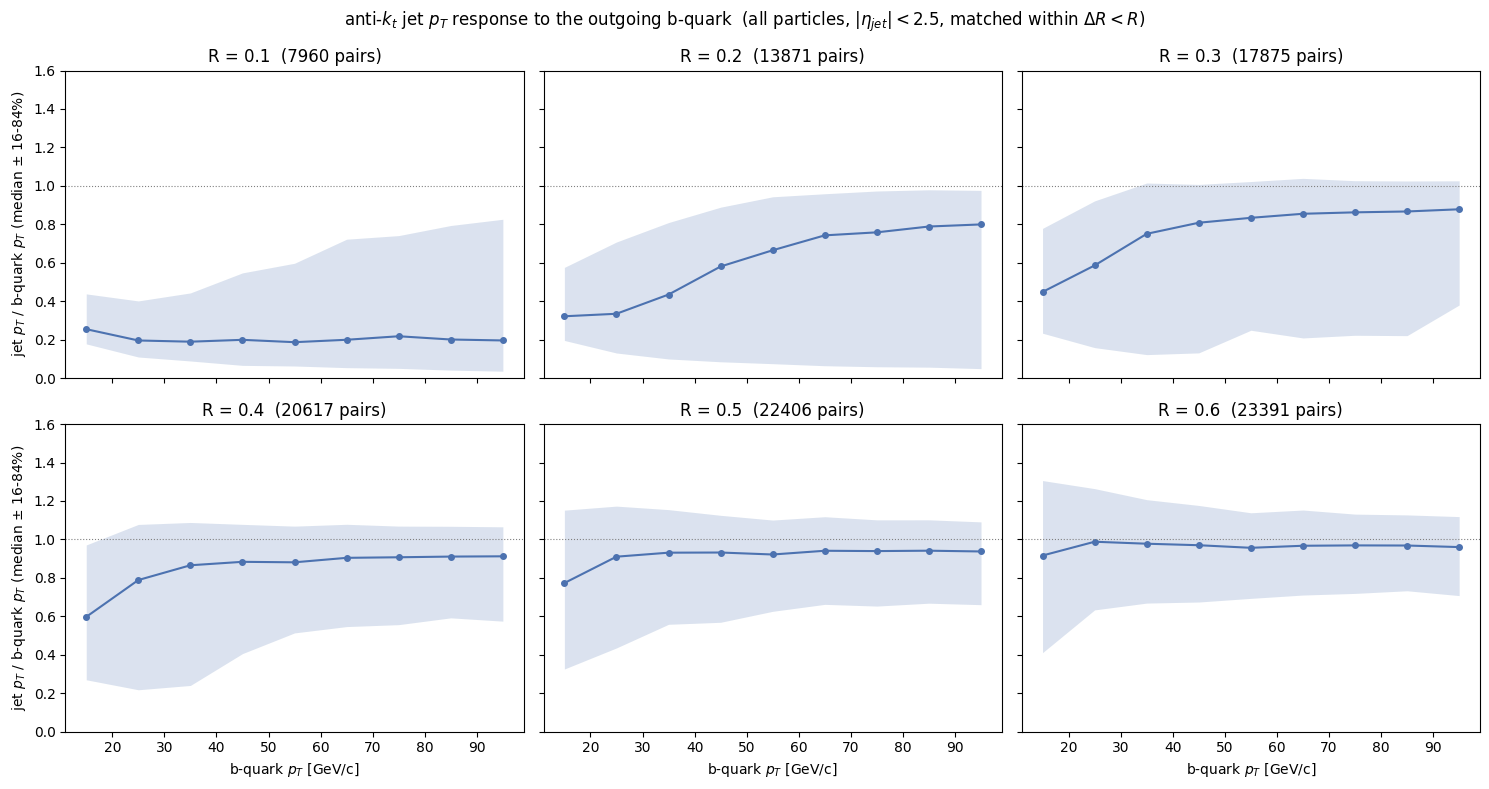

In [8]:
_ = plot_perR_ratio(data, r'anti-$k_t$ jet $p_T$ response to the outgoing b-quark  '
                          rf'(all particles, $|\eta_{{jet}}|<{eta_cut}$, matched within $\Delta R < R$)',
                    color=COLOR_ALL, savepath='demo_pythia_bjet_response_perR.png')

## Jet $p_T$ vs. b-quark $p_T$ correlation

Density of matched pairs in the (b-quark $p_T$, jet $p_T$) plane, using the full 10–100 GeV/c sample, one
panel per R. The dashed white line marks jet $p_T$ = b-quark $p_T$; the vertical spread at fixed b-quark
$p_T$ is the same resolution shown as bands in the profile plots above, just as raw pairs.

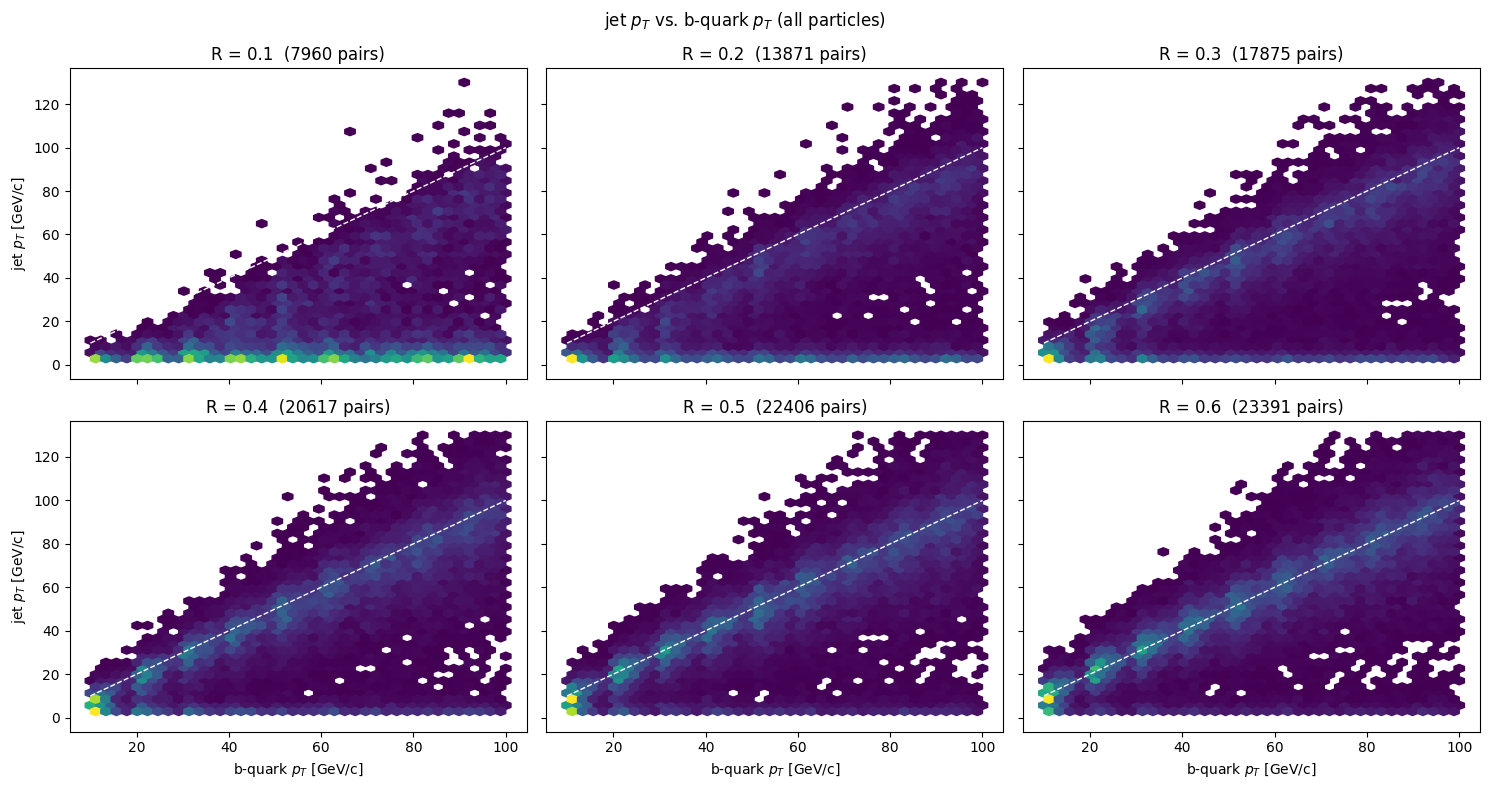

In [9]:
_ = plot_pt_correlation(data, r'jet $p_T$ vs. b-quark $p_T$ (all particles)',
                        savepath='demo_pythia_bjet_correlation.png')

## Matching debug: $\Delta y$ vs. $\Delta\phi$

Spatial distribution of matched (b-quark, jet) pairs around the jet axis, for the pT bin(s) listed in
`EXAMPLE_PT_BINS` (default: 50 GeV/c). We plot rapidity difference $\Delta y$, not pseudorapidity
$\Delta\eta$: FastJet's `delta_R()` -- the actual matching metric -- is defined with rapidity, and the
b-quark's mass (~4.8 GeV) makes the two differ measurably near threshold. Using $\Delta y$ keeps every point
inside the red $\Delta R = R$ circle, exactly consistent with the matching cut; plotting $\Delta\eta$ instead
would show a few points spilling outside it. Set `EXAMPLE_PT_BINS = list(pt_centers)` above and re-run to
produce one figure per pT bin instead of a single example.

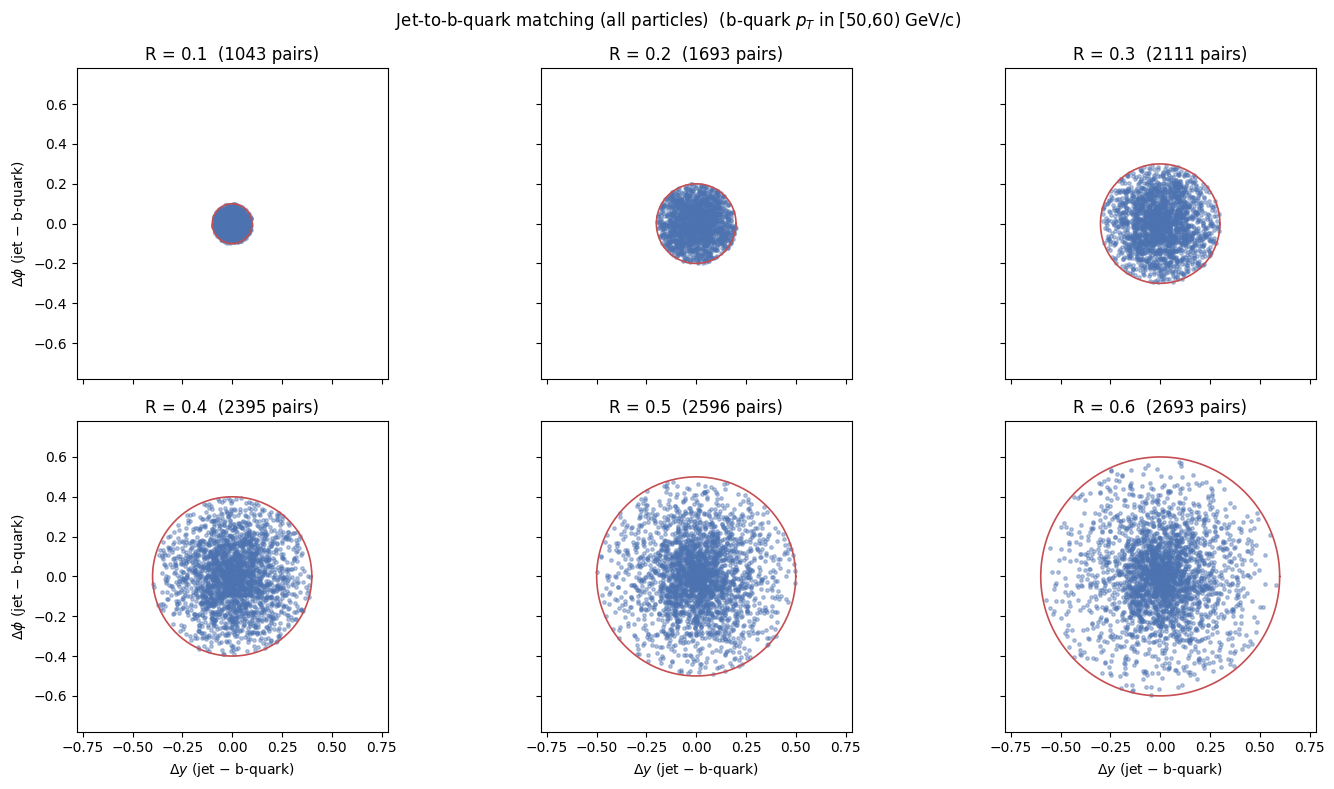

In [10]:
for pt_value in EXAMPLE_PT_BINS:
    plot_matching_debug(data, pt_value, 'Jet-to-b-quark matching (all particles)',
                        savepath=f'demo_pythia_bjet_matching_pt{pt_value:.0f}.png')

## Why do the 16-84% bands go above 1?

The bands in the per-R profile plots are raw percentiles of the jet $p_T$ / b-quark $p_T$ distribution, not a
hard-capped ratio -- a jet can pick up more transverse momentum than its matched b-quark carried, from
initial-/final-state radiation or multi-parton-interaction activity that happens to land inside the jet cone.
The histograms below (log-scale, same `EXAMPLE_PT_BINS`) show this directly: a tail above ratio = 1 that grows
with R (a bigger cone has more room to catch extra activity).

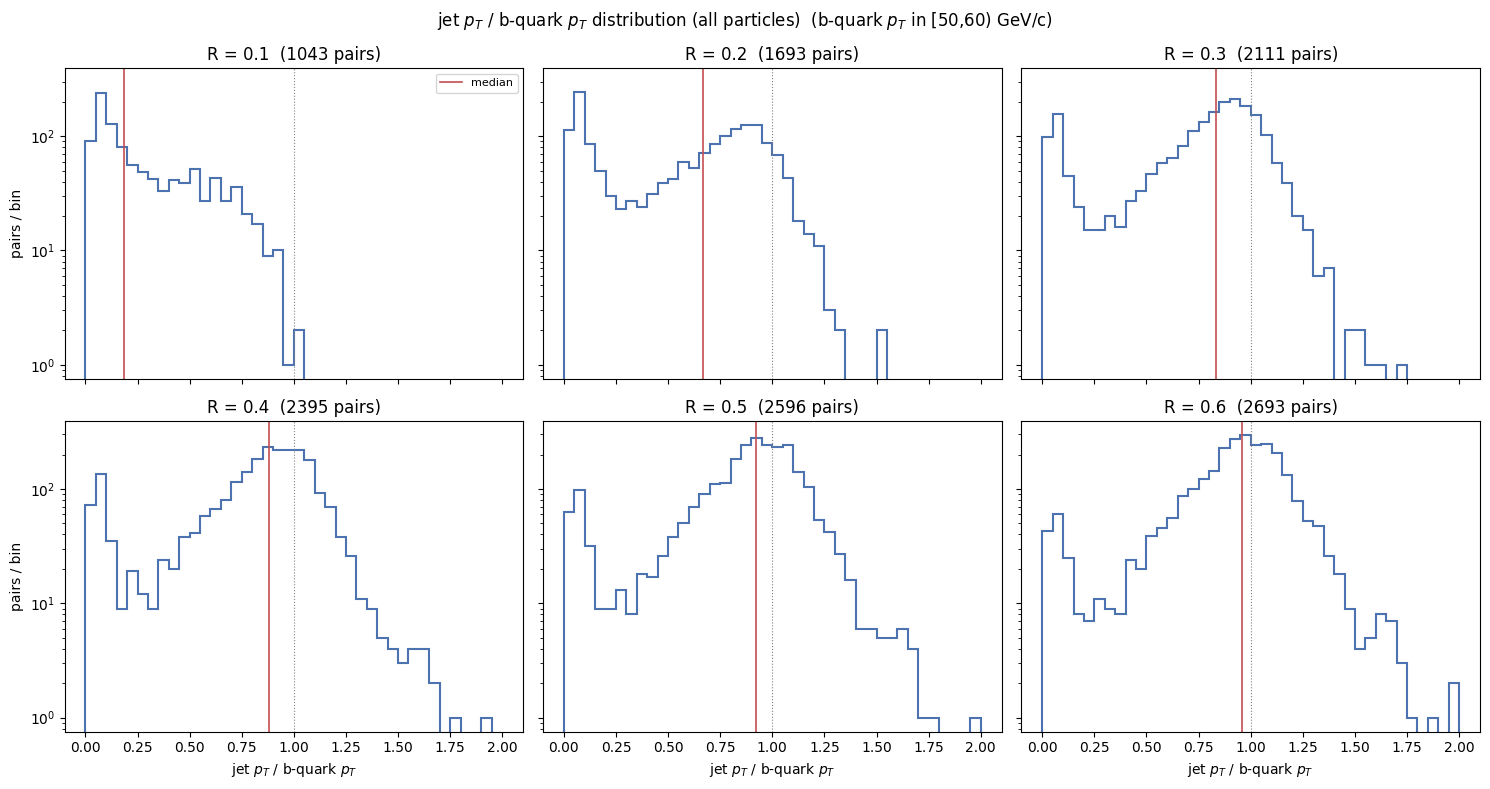

In [11]:
for pt_value in EXAMPLE_PT_BINS:
    plot_ratio_distribution(data, pt_value, 'jet $p_T$ / b-quark $p_T$ distribution (all particles)',
                            savepath=f'demo_pythia_bjet_ratio_dist_pt{pt_value:.0f}.png')

## Summary: most probable value vs. R and b-quark $p_T$

For every $(R, p_T\text{ bin})$ cell we take the *mode* of the jet $p_T$ / b-quark $p_T$ distribution,
estimated with a Gaussian KDE (more robust than the mean against the long low-side tail from out-of-cone
and semileptonic-decay losses, and much less noisy than a raw histogram argmax), and plot it vs. b-quark
$p_T$, with one curve per $R$.

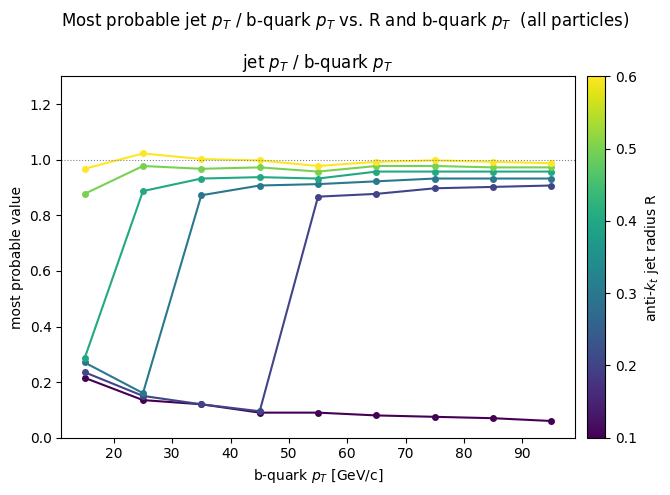

Matched-pair counts per (R, pT bin) -- low counts make the MPV noisy:
             15     25     35     45     55     65     75     85     95
R=0.1       246    532    739    884   1043   1028   1074   1197   1217
R=0.2       816   1287   1416   1500   1693   1668   1740   1860   1891
R=0.3      1312   1729   1868   1891   2111   2114   2168   2357   2325
R=0.4      1745   2045   2157   2198   2395   2400   2437   2614   2626
R=0.5      2004   2249   2356   2421   2596   2558   2605   2811   2806
R=0.6      2175   2368   2489   2526   2693   2645   2709   2887   2899


In [12]:
_ = plot_summary_mpv(data, 'Most probable jet $p_T$ / b-quark $p_T$ vs. R and b-quark $p_T$  (all particles)',
                     savepath='demo_pythia_bjet_response_summary.png')

**Reading the sharp jumps for R = 0.2, 0.3:** the response distribution at fixed $R$ and $p_T$ is genuinely
close to bimodal -- a b-quark's momentum is either largely "captured" by the jet cone (ratio near 1) or a
sizeable fraction escapes it (ratio well below 1), e.g. through wide-angle radiation or a semileptonic
B-decay neutrino. The KDE mode tracks whichever of the two humps is taller. As $p_T$ increases relative to a
fixed $R$, the decay/radiation products become more collimated and the "captured" hump overtakes the
"escaped" one, producing the single discontinuous step seen above rather than a smooth crossover. The 16-84%
bands in the per-R plots, and the ratio-distribution histograms further up, show this two-hump structure
directly.

## Charged-particle-only b-jets

Same analysis, but jets are clustered from charged final-state particles only (`track_types='charged'` in
`run_scan`), mimicking a track-based b-jet reconstruction. Charged jets carry only a fraction of the
all-particle energy/momentum -- roughly the charged fraction of the fragmentation products -- so the response
sits systematically lower, though the R-dependence is qualitatively similar.

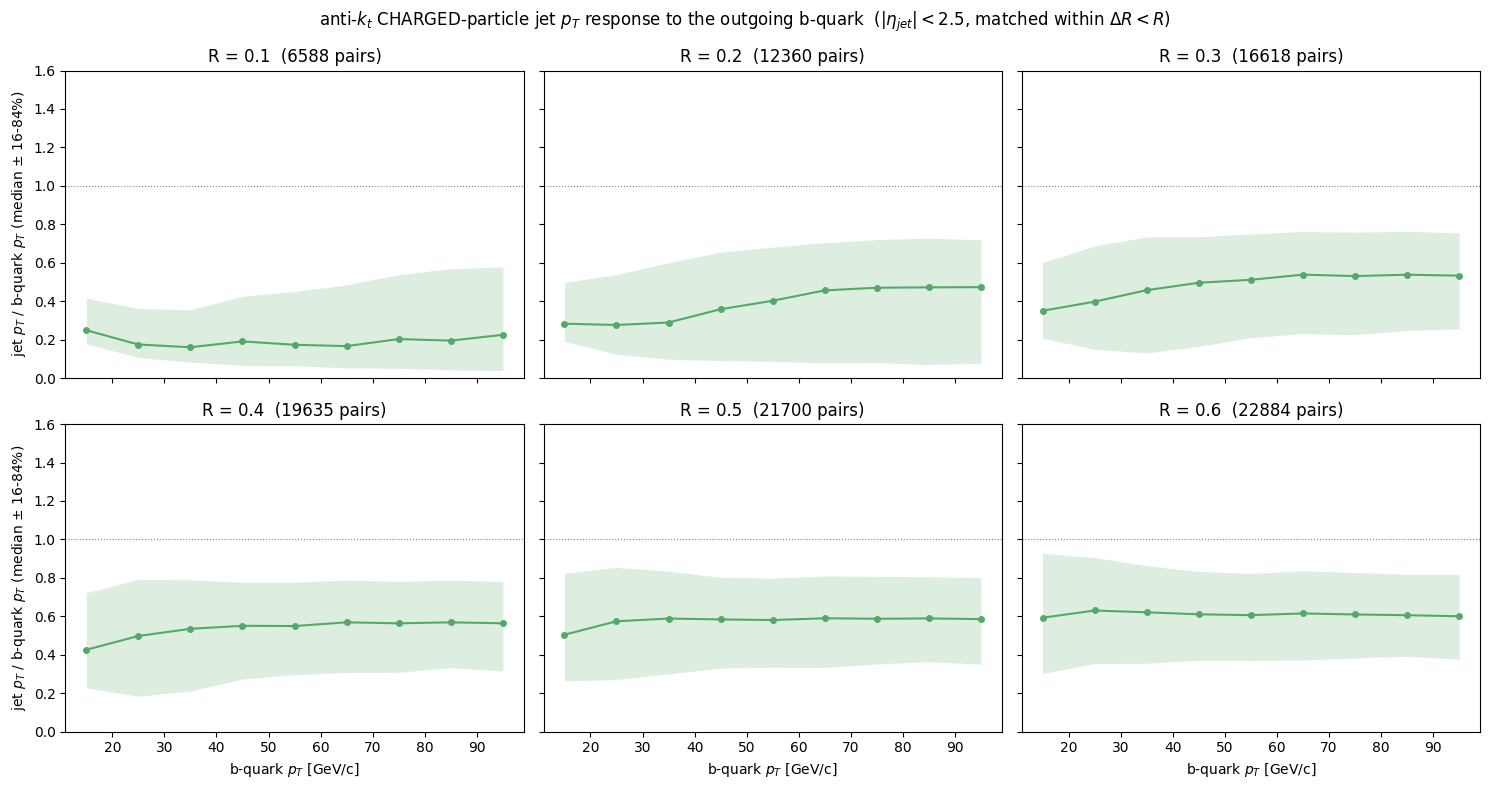

In [13]:
_ = plot_perR_ratio(data_charged, r'anti-$k_t$ CHARGED-particle jet $p_T$ response to the outgoing b-quark  '
                                  rf'($|\eta_{{jet}}|<{eta_cut}$, matched within $\Delta R < R$)',
                    color=COLOR_CHARGED, savepath='demo_pythia_bjet_response_perR_charged.png')

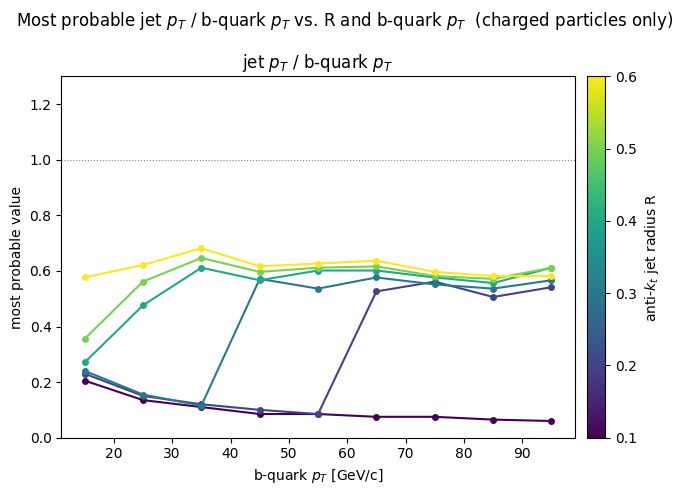

Matched-pair counts per (R, pT bin) -- low counts make the MPV noisy:
             15     25     35     45     55     65     75     85     95
R=0.1       166    378    579    703    841    878    929   1046   1068
R=0.2       555   1019   1256   1343   1548   1517   1610   1750   1762
R=0.3      1033   1492   1744   1759   2018   1988   2098   2250   2236
R=0.4      1486   1880   2087   2087   2335   2306   2353   2548   2553
R=0.5      1793   2133   2297   2336   2542   2511   2569   2757   2762
R=0.6      2007   2294   2456   2466   2656   2607   2684   2858   2856


In [14]:
_ = plot_summary_mpv(data_charged,
                     'Most probable jet $p_T$ / b-quark $p_T$ vs. R and b-quark $p_T$  (charged particles only)',
                     savepath='demo_pythia_bjet_response_summary_charged.png')